1. Importazione delle librerie necessarie

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns 
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score
from sklearn.metrics import  roc_curve, roc_auc_score
from sklearn.base import BaseEstimator, ClassifierMixin
import matplotlib.pyplot as plt
from art.estimators.classification import PyTorchClassifier # type: ignore
from art.attacks.evasion import FastGradientMethod
from art.defences.trainer import AdversarialTrainer


# Caricamento del dataset
attributes = ["Status_account", "Duration", "Credit_history", "Purpose",
              "Credit_amount", "Savings_account_bonds", "Employment_since", "Install_rate",
              "Personal_status_sex", "debtors_guarantors", "Present_residence_since",
              "Property", "Age", "Other_install_plans", "Housing", "No_credits", "Job",
              "No_people_liable", "Telephone", "foreign_worker", "good_bad"]

df = pd.read_csv("statlog+german+credit+data/german.data", sep=' ', names=attributes)

# Divisione in feature e target
X_not_encoded, X_test_not_encoded, y, y_test = train_test_split(
    df.drop(columns="good_bad"), df['good_bad'], stratify=df['good_bad'], train_size=0.8, random_state=15)

# Encoding
to_remove = ["Duration", "Credit_amount", "Install_rate", "Present_residence_since", "Age", "No_credits", "No_people_liable"]
to_be_encoded = [col for col in attributes if col not in to_remove and col != "good_bad"]

X_encoded = pd.get_dummies(X_not_encoded, columns=to_be_encoded, dtype=int)
X_test_encoded = pd.get_dummies(X_test_not_encoded, columns=to_be_encoded, dtype=int)

# Normalizzazione
scaler = MinMaxScaler()
X = scaler.fit_transform(X_encoded)
X_test = scaler.transform(X_test_encoded)

# Conversione del target
y = np.where(y == 2, 0, 1)
y_test = np.where(y_test == 2, 0, 1)

In [19]:
# confusion matrix
def confusion_matri(actual, predicted):
    cm = confusion_matrix(actual, predicted)
    tn, fp, fn, tp = cm.ravel()
    #plot confusion matrix
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt='.2f', 
                xticklabels =['Bad credit','Good credit'],
                yticklabels =['Bad credit','Good credit'])
    plt.ylabel('True Label')
    plt.xlabel('Predicted lable')
    plt.title("Confusion Matrix")
    plt.show()
    return tn,fp,fn,tp

# plotting roc-auc curve
def draw_roc(actual, proba):
    fpr, tpr, thresholds = roc_curve(actual, proba,drop_intermediate=False)
    auc_score = roc_auc_score(actual, proba)
    # plot the curve
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label="ROC curve(area={})".format(round(auc_score,2)))
    plt.plot([0,1],[0,1], 'k--')
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(visible=True, color='wheat', linestyle='--')
    plt.legend(loc="lower right")
    plt.title("ROC-AUC Curve")
    plt.show()
    return fpr, tpr, thresholds

3. Definizione del modello e della classe personalizzata per la ricerca iperparametrica

In [11]:
# Definizione del modello
class Model_classification_multi(nn.Module): 
    def __init__(self, in_features, out_features, hidden_1, hidden_2, hidden_3):
        super(Model_classification_multi, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, hidden_1),
            nn.ReLU(),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Linear(hidden_2, hidden_3),
            nn.ReLU(),
            nn.Linear(hidden_3, out_features)
        )
    
    def forward(self, x):
        return F.softmax(self.layers(x), dim=1)

class PyTorchClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, in_features, hidden_1, hidden_2, hidden_3, lr=0.001, epochs=50, batch_size=64):
        self.in_features = in_features
        self.hidden_1 = hidden_1
        self.hidden_2 = hidden_2
        self.hidden_3 = hidden_3
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.model = Model_classification_multi(in_features, 2, hidden_1, hidden_2, hidden_3)  # Modifica qui
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.CrossEntropyLoss()

    def fit(self, X, y):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.long)
        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
        
        for epoch in range(self.epochs):
            self.model.train()
            for batch_X, batch_y in loader:
                y_pred = self.model(batch_X)
                loss = self.loss_fn(y_pred, batch_y)
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()
        return self

    def predict(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            y_pred = self.model(X_tensor)
        return torch.argmax(y_pred, dim=1).numpy()

    def predict_proba(self, X):
        self.model.eval()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        with torch.no_grad():
            y_pred = self.model(X_tensor)
        return y_pred.numpy()

4. Ricerca degli Iperparametri con GridSearchCV

In [12]:
# Definizione del Grid per la ricerca degli iperparametri
param_grid = {
    'hidden_1': [64, 128],
    'hidden_2': [32, 64],
    'hidden_3': [16, 32],
    'lr': [0.001, 0.0001],
    'batch_size': [32, 64],
    'epochs': [50, 100]
}

In [13]:
# Implementazione di StratifiedKFold per preservare la distribuzione delle classi durante la ricerca
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=15)

# Inizializzazione del modello PyTorchClassifier
model = PyTorchClassifier(in_features=X.shape[1], hidden_1=64, hidden_2=32, hidden_3=16)

# Implementazione della ricerca degli iperparametri con GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=cv, scoring='accuracy', n_jobs=-1)
grid_search.fit(X, y)

# Migliori iperparametri
print(f"Migliori iperparametri trovati: {grid_search.best_params_}") 

/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:993: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/model_selection/_validation.py", line 982, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 253, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
  File "/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 345, in _score
    y_pred = method_caller(
  File "/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/metrics/_scorer.py", line 87, in _cached_call
    result, _ = _get_response_values(
  File "/home/mrnbd/.local/lib/python3.10/site-packages/sklearn/utils/_response.py", line 198, in _ge

Migliori iperparametri trovati: {'batch_size': 32, 'epochs': 50, 'hidden_1': 64, 'hidden_2': 32, 'hidden_3': 16, 'lr': 0.001}


5. Valutazione delle tre configurazioni

In [14]:
# Utilizzo del modello con i migliori iperparametri per la valutazione
best_model = grid_search.best_estimator_

# Previsione
y_pred = best_model.predict(X_test)

# Confusion Matrix e Classification Report
print("Senza PCA e senza SMOTE:")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
final_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {final_accuracy:.4f}")

Senza PCA e senza SMOTE:
[[ 27  33]
 [ 16 124]]
              precision    recall  f1-score   support

           0       0.63      0.45      0.52        60
           1       0.79      0.89      0.84       140

    accuracy                           0.76       200
   macro avg       0.71      0.67      0.68       200
weighted avg       0.74      0.76      0.74       200

Accuracy: 0.7550


In [17]:
from art.attacks.evasion import FastGradientMethod
from art.estimators.classification import PyTorchClassifier as ARTClassifier

# Converti X_test a Float32
X_test = X_test.astype(np.float32)

# Creazione di un ARTClassifier per avvolgere il modello PyTorch
art_model = ARTClassifier(
    model=best_model.model,  # Ora puoi accedere direttamente al modello PyTorch
    clip_values=(0, 1),  # I valori dei tuoi input sono già normalizzati tra 0 e 1
    loss=nn.CrossEntropyLoss(),
    optimizer=best_model.optimizer,
    input_shape=(X.shape[1],),
    nb_classes=2
)

# Creazione dell'attacco Fast Gradient Method
attack = FastGradientMethod(estimator=art_model, eps=0.2)

# Generazione degli esempi avversari per il set di test
X_test_adv = attack.generate(x=X_test)

# Previsione sugli esempi avversari
y_pred_adv = best_model.predict(X_test_adv)

# Confusion Matrix e Classification Report sugli esempi avversari
print("Risultati sugli esempi avversari generati con FGM:")
print(confusion_matrix(y_test, y_pred_adv))
print(classification_report(y_test, y_pred_adv))
final_accuracy_adv = accuracy_score(y_test, y_pred_adv)
print(f"Accuracy sugli esempi avversari: {final_accuracy_adv:.4f}")


Risultati sugli esempi avversari generati con FGM:
[[ 35  25]
 [118  22]]
              precision    recall  f1-score   support

           0       0.23      0.58      0.33        60
           1       0.47      0.16      0.24       140

    accuracy                           0.28       200
   macro avg       0.35      0.37      0.28       200
weighted avg       0.40      0.28      0.26       200

Accuracy sugli esempi avversari: 0.2850


In [20]:
import numpy as np
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from art.estimators.classification import PyTorchClassifier as ARTClassifier
from art.attacks.evasion import FastGradientMethod
from art.defences.trainer import AdversarialTrainer

# Wrap the trained PyTorch model with ART PyTorchClassifier
classifier = ARTClassifier(
    model=best_model.model,
    loss=best_model.loss_fn,
    optimizer=best_model.optimizer,
    input_shape=(X.shape[1],),
    nb_classes=2,
    clip_values=(0, 1)  # Assuming your data is normalized between 0 and 1
)

# Convert test data to float32
X_test = X_test.astype(np.float32)

# Test the model's accuracy on the original test samples
predictions = classifier.predict(X_test)
predictions_binary = np.where(predictions[:, 1] > 0.5, 1, 0)  # Thresholding to convert probabilities to binary
accuracy = accuracy_score(y_test, predictions_binary)
print(f"Original test data accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_test, predictions_binary))
print(confusion_matrix(y_test, predictions_binary))

# Eseguire un attacco di evasione (FGSM) sui campioni di test
attack = FastGradientMethod(estimator=classifier, norm=2, eps=0.3)
X_test_adv = attack.generate(x=X_test)  # Genera esempi adversariali

# Test dell'accuratezza del modello sui campioni di test adversariali
predictions_adv = classifier.predict(X_test_adv)
predictions_adv_binary = np.where(predictions_adv[:, 1] > 0.5, 1, 0)  # Thresholding to convert probabilities to binary
accuracy_adv = accuracy_score(y_test, predictions_adv_binary)
print(f"Adversarial test data accuracy: {accuracy_adv * 100:.2f}%")
print(classification_report(y_test, predictions_adv_binary))

# Difendere il modello contro l'attacco di evasione usando l'adversarial training
adv_trainer = AdversarialTrainer(classifier, attacks=attack, ratio=0.5)
adv_trainer.fit(x=X_test, y=y_test, batch_size=100, nb_epochs=10)

# Rivalutare l'accuratezza del modello sui campioni di test originali dopo l'adversarial training
predictions_def = classifier.predict(X_test)
predictions_def_binary = np.where(predictions_def[:, 1] > 0.5, 1, 0)  # Thresholding to convert probabilities to binary
accuracy_def = accuracy_score(y_test, predictions_def_binary)
print(f"Defended test data accuracy: {accuracy_def * 100:.2f}%")

# Rivalutare l'accuratezza del modello sui campioni di test adversariali dopo l'adversarial training
predictions_adv_def = classifier.predict(X_test_adv)
predictions_adv_def_binary = np.where(predictions_adv_def[:, 1] > 0.5, 1, 0)  # Thresholding to convert probabilities to binary
accuracy_adv_def = accuracy_score(y_test, predictions_adv_def_binary)
print(f"Defended adversarial test data accuracy: {accuracy_adv_def * 100:.2f}%")


Original test data accuracy: 75.50%
              precision    recall  f1-score   support

           0       0.63      0.45      0.52        60
           1       0.79      0.89      0.84       140

    accuracy                           0.76       200
   macro avg       0.71      0.67      0.68       200
weighted avg       0.74      0.76      0.74       200

[[ 27  33]
 [ 16 124]]
Adversarial test data accuracy: 63.50%
              precision    recall  f1-score   support

           0       0.39      0.40      0.40        60
           1       0.74      0.74      0.74       140

    accuracy                           0.64       200
   macro avg       0.57      0.57      0.57       200
weighted avg       0.64      0.64      0.64       200



Precompute adv samples:   0%|          | 0/1 [00:00<?, ?it/s]

Adversarial training epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Defended test data accuracy: 79.50%
Defended adversarial test data accuracy: 76.50%


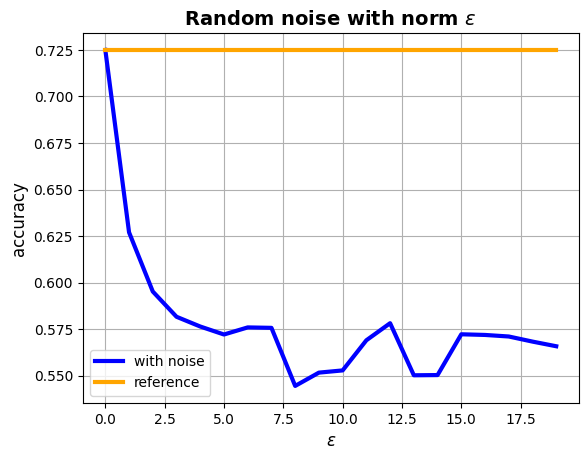

In [7]:
# Funzione per la valutazione del modello
def evaluate_best(X, y, model, only_score=False, scoring=balanced_accuracy_score):
    y_pred = model.predict(X)
    if only_score:
        return scoring(y, y_pred)
    else:
        print(confusion_matrix(y, y_pred))
        print(classification_report(y, y_pred))
        return scoring(y, y_pred)

# Ciclo di test del rumore
eps_x = np.arange(0, 20, 1)  # Iniziare da 0 per includere il caso senza rumore
eps_acc = [final_accuracy]  # Include the final accuracy at eps = 0

noisyy = y_test.copy()

for eps in eps_x[1:]:  # Skip the first element (0) since we already have that accuracy
    acc_vs = []
    for _ in range(10):
        noise = np.clip(np.random.normal(0, eps / np.sqrt(X_test.shape[1]), X_test.shape), -0.5, 0.5)
        noisyX = X_test + noise
        acc = evaluate_best(noisyX, noisyy, model=best_model, only_score=True, scoring=balanced_accuracy_score)
        acc_vs.append(acc)
    if eps in [0.5, 19.5]:  # Show confusion matrix at these points
        evaluate_best(noisyX, noisyy, model=best_model, scoring=balanced_accuracy_score)
    eps_acc.append(np.mean(acc_vs))

# Plot dei risultati
plt.plot(eps_x, eps_acc, color='blue', label='with noise', linewidth=3)
plt.plot(eps_x, [final_accuracy] * len(eps_x), color='orange', label='reference', linewidth=3)
plt.title('Random noise with norm $\\epsilon$', fontsize=14, fontweight='bold')
plt.xlabel('$\\epsilon$', fontsize=12)
plt.ylabel('accuracy', fontsize=12)
plt.legend()
plt.grid(True)
plt.show()